In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from rapidfuzz import fuzz, process
from sklearn.model_selection import cross_validate
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import SparsePCA
from sklearn.model_selection import train_test_split
from joblib import Parallel, delayed

from scholarlm.utils import (
    load_and_process_results,
    match_datasets,
    matching_precision_recall,
)
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

INFO 02-19 08:49:33 [__init__.py:216] Automatically detected platform cuda.


### Ground Truth Dataset

In [9]:
# ---------------------------------
# Load from ground truth dataset
# ---------------------------------

# Directory
with open(os.path.join("../data/pond/directory.json"), "r") as f:
    paper_info = json.load(f)

paper_subset = [
    'physical_and_chemical_limnological',
    'physical-chemical_influences',
    'prairie_wetland',
    'net_heterotrophy',
    'habitat_characteristics',
    'biodiversity_of_constructed',
    'fish_production_in_lakes',
    'long-term_stability',
    'diversity_of_macroinvertebrates',
    'impact_of_macrophytes'
]

paper_subset = [
    'physical-chemical_influences',
    'environmental_conditions',
    'relative_contribution',
    'monitoring_status',
    'characterizing_ponds',
    'diversity_of_macroinvertebrates',
    'impact_of_macrophytes',
    'macroinvertebrate_size',
    'biodiversity_of_constructed',
    'conservation_of_pond',
]


#paper_info = {k:v for k,v in paper_info.items() if k in paper_subset}
registered_titles = [entry['title'] for entry in paper_info.values()]
registered_titles.sort()

ground_truth_df = pd.read_csv("../data/pond/pond_data_corrected.csv", encoding_errors='ignore', index_col = 0)
ground_truth_df = ground_truth_df.loc[ground_truth_df.title.isin(registered_titles)]
ground_truth_df = ground_truth_df.reset_index(drop=True)

In [10]:
ground_truth_df

,author,title,name,location,ecosystem,date,state,attribute,value
0,chopyk et al.,agricultural freshwater pond supports diverse ...,NaN,central maryland; usa,ponds,NaN,NaN,max_depth,3.35
1,chopyk et al.,agricultural freshwater pond supports diverse ...,NaN,central maryland; usa,ponds,NaN,NaN,ph,7.78
2,chopyk et al.,agricultural freshwater pond supports diverse ...,NaN,central maryland; usa,ponds,NaN,NaN,surface_area,2600.00
3,tudor; m.; tudor; i-m; ibram; o.; teodorof; l....,analysis of biological indicators related to t...,cuibul cu lebede lake,danube delta,shallow lake,NaN,NaN,ph,8.03
4,tudor; m.; tudor; i-m; ibram; o.; teodorof; l....,analysis of biological indicators related to t...,isac lake,danube delta,shallow lake,NaN,NaN,ph,7.75
...,...,...,...,...,...,...,...,...,...
3405,gilbert; juan diego; de vicente; inmaculada; j...,zooplankton body size versus taxonomy in medit...,casillas,alto guadalquivir region of spain,mediterranean wetland,NaN,NaN,tp,206.70
3406,gilbert; juan diego; de vicente; inmaculada; j...,zooplankton body size versus taxonomy in medit...,quinta,alto guadalquivir region of spain,mediterranean wetland,NaN,NaN,tp,49.10
3407,gilbert; juan diego; de vicente; inmaculada; j...,zooplankton body size versus taxonomy in medit...,ardal,alto guadalquivir region of spain,mediterranean wetland,NaN,NaN,tp,150.90
3408,gilbert; juan diego; de vicente; inmaculada; j...,zooplankton body size versus taxonomy in medit...,hituelo,alto guadalquivir region of spain,mediterranean wetland,NaN,NaN,tp,55.50


### Extracted Dataset

In [5]:
# ---------------------------------
# Load experiment results
# ---------------------------------

experiment_data_path = "../data/experiments/2026_02_25/pond.json"

unit_conversion_table = {
    'max_depth': {"cm": 0.01, "feet": 0.3048, "km": 1000, "m": 1},
    'surface_area': {"km^2": 1e6, "ha": 1e4, "mi^2": 2.59e6, "m^2": 1, "acres": 4046.86},
    'vegetation_cover': {"percent": 1.0, "fraction": 100.0},
    'tn': {"mg/L": 1000.0, "µg/L": 1.0, "μmol/L": 14.01, "ppm": 1000.0, "ppb": 1.0},
    'tp': {"mg/L": 1000.0, "µg/L": 1.0, "μmol/L": 30.97, "ppm": 1000.0, "ppb": 1.0},
    'chla': {"mg/L": 1000.0, "µg/L": 1.0, "mg/m^3": 1.0},
    'ph': {},
    'latitude': {},
    'longitude': {}
}

attribute_types = {
    'max_depth': float,
    'surface_area': float,
    'vegetation_cover': float,
    'tn': float,
    'tp': float,
    'chla': float,
    'ph': float,
    'latitude': float,
    'longitude': float
}

# NOTE: some of these things you should get rid of in your extraction process!
drop_keys = ["feature_terms", "attribute_terms", "abbreviations", "table_logprob", "page_logprob", "judgement_raw_text"]
drop_attrs = ['latitude', 'longitude']

extracted_df = load_and_process_results(
    json_path=experiment_data_path,
    unit_conversion_table=unit_conversion_table,
    attribute_types=attribute_types,
    drop_keys=drop_keys,
    drop_attrs=drop_attrs,
    attribute_col="attribute", # NOTE you need to change this to 'attribute' #NOTE or back to feature!!!
    value_col="value",
    unit_col="units",
    out_col="processed_value"
)

# NOTE you need to change this to 'attribute'
extracted_df.rename(columns={"feature": "attribute"}, inplace=True)
extracted_df.sort_values(by=["title", "attribute"], inplace=True)
extracted_df.reset_index(drop=True, inplace=True)

In [6]:
#extracted_df.judgement_llama = extracted_df.judgement_llama == 'true'

In [7]:
extracted_df

,title,author,year,paper_code,document_id,context,name,location,site,state,...,attribute,value,units,page_number,source,measurement_id,table_number,row_index,column_index,processed_value
0,agricultural freshwater pond supports diverse ...,chopyk et al.,2018,agricultural_freshwater,0,"standard, ponds are generally defined as small...",Agricultural Pond,Mid-Atlantic United States,None,None,...,max_depth,3.35,meters,1.0,text,1,NaN,NaN,NaN,3.35
1,agricultural freshwater pond supports diverse ...,chopyk et al.,2018,agricultural_freshwater,0,"standard, ponds are generally defined as small...",Agricultural Pond,Mid-Atlantic United States,1 μm filter,None,...,max_depth,3.35,meters,1.0,text,5,NaN,NaN,NaN,3.35
2,agricultural freshwater pond supports diverse ...,chopyk et al.,2018,agricultural_freshwater,0,"standard, ponds are generally defined as small...",Agricultural Pond,Mid-Atlantic United States,0.2 μm filter,None,...,max_depth,3.35,meters,1.0,text,9,NaN,NaN,NaN,3.35
3,agricultural freshwater pond supports diverse ...,chopyk et al.,2018,agricultural_freshwater,0,"standard, ponds are generally defined as small...",Agricultural Pond,Mid-Atlantic United States,1 μm filter,None,...,max_depth,3.35,meters,1.0,text,13,NaN,NaN,NaN,3.35
4,agricultural freshwater pond supports diverse ...,chopyk et al.,2018,agricultural_freshwater,0,"standard, ponds are generally defined as small...",Agricultural Pond,Mid-Atlantic United States,0.2 μm filter,None,...,max_depth,3.35,meters,1.0,text,17,NaN,NaN,NaN,3.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7289,zooplankton body size versus taxonomy in medit...,gilbert; juan diego; de vicente; inmaculada; j...,2017,zooplankton_body,127,"<table number=""1"">\n <caption>Table 1. Mean (...",Ardal wetland,"Alto Guadalquivir region, southern Spain",None,None,...,tp,150.9,μg/L,NaN,table,8455,1.0,"('Ardal','Total P')",mean,150.9
7290,zooplankton body size versus taxonomy in medit...,gilbert; juan diego; de vicente; inmaculada; j...,2017,zooplankton_body,127,"<table number=""1"">\n <caption>Table 1. Mean (...",Santisteban wetland,"Alto Guadalquivir region, southern Spain",None,None,...,tp,122.3,μg/L,NaN,table,8461,1.0,"('Santisteban','Total P')",mean,122.3
7291,zooplankton body size versus taxonomy in medit...,gilbert; juan diego; de vicente; inmaculada; j...,2017,zooplankton_body,127,"<table number=""1"">\n <caption>Table 1. Mean (...",Hituelo wetland,"Alto Guadalquivir region, southern Spain",None,None,...,tp,55.5,μg/L,NaN,table,8467,1.0,"('Hituelo','Total P')",mean,55.5
7292,zooplankton body size versus taxonomy in medit...,gilbert; juan diego; de vicente; inmaculada; j...,2017,zooplankton_body,127,"<table number=""1"">\n <caption>Table 1. Mean (...",Quinta wetland,"Alto Guadalquivir region, southern Spain",None,None,...,tp,49.1,μg/L,NaN,table,8473,1.0,"('Quinta','Total P')",mean,49.1


### Match Extractions to Ground Truth

In [11]:
# Set of attributes which must be strictly equivalent to create a match
strict_matching = {
    "title": "title", # name in the ground truth dataset : name in the extracted dataset
    "attribute": "attribute",
    "value": "processed_value"
}

# Set of attributes which should be 
# compared by a fuzzy matching (roughly similar) to create a match.
fuzzy_matching = {
    "name": "name",
    "location": "location",
    "ecosystem": "ecosystem",
}

# This can take a while to run if you have a lot of data, 
# since it compares every extracted row to every ground truth row.
matching, edges, edge_weights = match_datasets(
    ground_truth_df,
    extracted_df,
    strict_matching=strict_matching,
    fuzzy_matching=fuzzy_matching
)

recall = len(matching) / len(ground_truth_df)
print(f"Recall: {recall:.4f}")

Recall: 0.6786


### Debugging:

In [29]:
gt_matched = np.array([False] * ground_truth_df.shape[0])
ex_matched = np.array([False] * extracted_df.shape[0])
for gt_idx, ex_idx in matching:
    gt_matched[gt_idx] = True
    ex_matched[ex_idx] = True

unmatched_gt = np.where(~gt_matched)[0]
unmatched_ex = np.where(~ex_matched)[0]

matched_gt_df = ground_truth_df[gt_matched == True]
unmatched_gt_df = ground_truth_df[gt_matched == False]
unmatched_gt_titles = unmatched_gt_df.title.value_counts().index

matched_ex_df = extracted_df[ex_matched == True]
unmatched_ex_df = extracted_df[ex_matched == False]
unmatched_ex_titles = unmatched_ex_df.title.value_counts().index

In [78]:
unmatched_gt_df.title.value_counts().head(10)

title
physical-chemical influences on vernal zooplankton community structure in small lakes and wetlands of wisconsin; usa                                                               96
environmental conditions and macrophytes of karst ponds                                                                                                                            84
relative contribution of small mountain ponds to regional richness of littoral macroinvertebrates and the implications for conservation                                            78
characterizing ponds in a watershed simulation and evaluating their influence on streamflow in a mississippi watershed                                                             67
impact of macrophytes on phytoplankton in eutrophic peri-urban ponds; implications for pond management and restoration                                                             56
biodiversity of constructed wetlands for wastewater treatment                       

In [68]:
unmatched_gt_df.title.value_counts().head(10)

title
environmental conditions and macrophytes of karst ponds                                                                                                                            81
relative contribution of small mountain ponds to regional richness of littoral macroinvertebrates and the implications for conservation                                            77
physical and chemical limnological characteristics of 38 lakes and ponds on bathurst island; nunavut; canadian high arctic                                                         74
characterizing ponds in a watershed simulation and evaluating their influence on streamflow in a mississippi watershed                                                             67
impact of macrophytes on phytoplankton in eutrophic peri-urban ponds; implications for pond management and restoration                                                             63
relationships between fish feeding guild and trophic structure in english lowland sh

In [20]:
matched_gt_df.title.value_counts()

title
vegetation-environmental variable relationships in ponds of various origins along an altitudinal gradient                        43
distinct optical chemistry of dissolved organic matter in urban pond ecosystems                                                  29
productivity and depth regulate lake contributions to atmospheric methane                                                        19
lake morphometry moderates the relationship between water color and fish biomass in small boreal lakes                           16
sediment characteristics and accumulation rates in constructed ponds                                                             10
natural variability of carbon dioxide and net epilimnetic production in the surface waters of boreal lakes of different sizes     4
fish assemblages in floodplain lakes in a neotropical river during the wet season (magdalena river; colombia)                     3
conservation of pond systems: a case study of intractability; brown mo

In [85]:
title = "biodiversity of constructed wetlands for wastewater treatment"
gt_title_df = ground_truth_df.loc[ground_truth_df.title == title]
unmatched_gt_title_df = unmatched_gt_df.loc[unmatched_gt_df.title == title]
ex_title_df = extracted_df.loc[extracted_df.title == title]
unmatched_ex_title_df = unmatched_ex_df.loc[unmatched_ex_df.title == title]

In [92]:
unmatched_gt_title_df.loc[unmatched_gt_title_df.attribute == "surface_area"]

,author,title,name,location,ecosystem,date,state,attribute,value
26,hsu,biodiversity of constructed wetlands for waste...,hs2-1,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,NaN,NaN,surface_area,1000.0
27,hsu,biodiversity of constructed wetlands for waste...,hs2-2,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,NaN,NaN,surface_area,6000.0
28,hsu,biodiversity of constructed wetlands for waste...,hs2-3,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,NaN,NaN,surface_area,5500.0
29,hsu,biodiversity of constructed wetlands for waste...,hs2-4,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,NaN,NaN,surface_area,6000.0
30,hsu,biodiversity of constructed wetlands for waste...,hs2-5,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,NaN,NaN,surface_area,6500.0
32,hsu,biodiversity of constructed wetlands for waste...,dn2,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,NaN,NaN,surface_area,6500.0
33,hsu,biodiversity of constructed wetlands for waste...,dn3-a,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,NaN,NaN,surface_area,2600.0
34,hsu,biodiversity of constructed wetlands for waste...,dn3-b,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,NaN,NaN,surface_area,6000.0
35,hsu,biodiversity of constructed wetlands for waste...,dn3-c,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,NaN,NaN,surface_area,7500.0
36,hsu,biodiversity of constructed wetlands for waste...,dn3-d,da-han river; taipei county; taiwan,treatment cells in constructed wetlands,NaN,NaN,surface_area,2600.0


In [90]:
ex_title_df.loc[ex_title_df.attribute == "surface_area"]

,title,author,year,paper_code,document_id,name,location,site,state,date,...,context,attribute,value,units,page_number,source,table_number,row_index,column_index,processed_value
30,biodiversity of constructed wetlands for waste...,hsu,2011,biodiversity_of_constructed,8,Depositional pond (Hsin-Hai II),"Taipei County, Taiwan",HS2-1,None,2009-2010,...,macroinvertebrates with environmental variable...,surface_area,0.200,ha,4.0,text,NaN,NaN,NaN,2000.000
31,biodiversity of constructed wetlands for waste...,hsu,2011,biodiversity_of_constructed,8,Depositional pond (Hsin-Hai II),"Taipei County, Taiwan",HS2-1,None,2009-2010,...,"<table number=""1"">\n <caption>Table 1. Design...",surface_area,4.700,ha,NaN,table,1.0,HS2,Total area (ha),47000.000
32,biodiversity of constructed wetlands for waste...,hsu,2011,biodiversity_of_constructed,8,Depositional pond (Hsin-Hai II),"Taipei County, Taiwan",HS2-1,None,2009-2010,...,"<table number=""6"">\n <caption>Table 6. Best s...",surface_area,-0.691,None,NaN,table,6.0,"('Aquatic macroinvertebrates','Density','Wetla...",Parameter estimate,-0.691
33,biodiversity of constructed wetlands for waste...,hsu,2011,biodiversity_of_constructed,8,Depositional pond (Daniaopi),"Taipei County, Taiwan",DN1,None,2009-2010,...,macroinvertebrates with environmental variable...,surface_area,0.200,ha,4.0,text,NaN,NaN,NaN,2000.000
34,biodiversity of constructed wetlands for waste...,hsu,2011,biodiversity_of_constructed,8,Depositional pond (Daniaopi),"Taipei County, Taiwan",DN1,None,2009-2010,...,"<table number=""1"">\n <caption>Table 1. Design...",surface_area,13.000,ha,NaN,table,1.0,DN,Total area (ha),130000.000
35,biodiversity of constructed wetlands for waste...,hsu,2011,biodiversity_of_constructed,8,Depositional pond (Daniaopi),"Taipei County, Taiwan",DN1,None,2009-2010,...,"<table number=""6"">\n <caption>Table 6. Best s...",surface_area,-0.691,None,NaN,table,6.0,"('Aquatic macroinvertebrates','Density','Wetla...",Parameter estimate,-0.691
36,biodiversity of constructed wetlands for waste...,hsu,2011,biodiversity_of_constructed,8,Hsin-Hai II Constructed Wetland,"Taipei County, Taiwan","HS2-1, HS2-2, HS2-3, HS2-4, HS2-5",None,2009-2010,...,"<table number=""1"">\n <caption>Table 1. Design...",surface_area,4.700,ha,NaN,table,1.0,HS2,Total area (ha),47000.000
37,biodiversity of constructed wetlands for waste...,hsu,2011,biodiversity_of_constructed,8,Hsin-Hai II Constructed Wetland,"Taipei County, Taiwan","HS2-1, HS2-2, HS2-3, HS2-4, HS2-5",None,2009-2010,...,"<table number=""6"">\n <caption>Table 6. Best s...",surface_area,8.522,None,NaN,table,6.0,"('Birds','Species richness','Wetland area')",Parameter estimate,8.522
38,biodiversity of constructed wetlands for waste...,hsu,2011,biodiversity_of_constructed,8,Daniaopi Constructed Wetland,"Taipei County, Taiwan","DN1, DN2, DN3-A, DN3-B, DN3-C, DN3-D, DN4, DN5",None,2009-2010,...,"<table number=""1"">\n <caption>Table 1. Design...",surface_area,13.000,ha,NaN,table,1.0,DN,Total area (ha),130000.000
39,biodiversity of constructed wetlands for waste...,hsu,2011,biodiversity_of_constructed,8,Daniaopi Constructed Wetland,"Taipei County, Taiwan","DN1, DN2, DN3-A, DN3-B, DN3-C, DN3-D, DN4, DN5",None,2009-2010,...,"<table number=""6"">\n <caption>Table 6. Best s...",surface_area,8.522,None,NaN,table,6.0,"('Birds','Species richness','Wetland area')",Parameter estimate,8.522


### Judgement

In [20]:
# First we create a set of validation labels, which are taken as the union of 
# matching results and combined (voted) LLM judgements.
matching_status = np.zeros(len(extracted_df), dtype=bool)
for gt_idx, ex_idx in matching:
    matching_status[ex_idx] = True

extracted_df['validation'] = extracted_df['judgement_combined'] | matching_status
labels = extracted_df['validation'].astype(bool).to_numpy()

In [21]:
# Next we can asses how well each judge does individually to predict 
# the validation labels.

prediction_dict = {
    "llama": extracted_df['judgement_llama'],
    "gpt": extracted_df['judgement_gpt'],
    "gemini": extracted_df['judgement_gemini'],
    "claude": extracted_df['judgement_claude'],
}

for model_name, preds_series in prediction_dict.items():
    preds = preds_series.astype(bool).to_numpy()

    tp = int(((preds == True) & (labels == True)).sum())
    tn = int(((preds == False) & (labels == False)).sum())
    fp = int(((preds == True) & (labels == False)).sum())
    fn = int(((preds == False) & (labels == True)).sum())

    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else float('nan')
    precision = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    recall = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else float('nan')
    denom = fp + tn
    fpr = (fp / denom) if denom > 0 else float('nan')

    print(f"Model: {model_name}")
    print(f"  TP={tp}, FP={fp}, TN={tn}, FN={fn}")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"  FPR:       {fpr:.4f}")
    print()

Model: llama
  TP=1759, FP=384, TN=1824, FN=2293
  Accuracy:  0.5724
  Precision: 0.8208
  Recall:    0.4341
  F1:        0.5679
  FPR:       0.1739

Model: gpt
  TP=3628, FP=50, TN=2158, FN=424
  Accuracy:  0.9243
  Precision: 0.9864
  Recall:    0.8954
  F1:        0.9387
  FPR:       0.0226

Model: gemini
  TP=3933, FP=285, TN=1923, FN=119
  Accuracy:  0.9355
  Precision: 0.9324
  Recall:    0.9706
  F1:        0.9511
  FPR:       0.1291

Model: claude
  TP=3808, FP=158, TN=2050, FN=244
  Accuracy:  0.9358
  Precision: 0.9602
  Recall:    0.9398
  F1:        0.9499
  FPR:       0.0716



#### Llama Attention Probing
We can improve the accuracy of the Llama judge by studying its internal attention patterns. 

In [22]:
def grouped_kfold_split(titles, n_splits=5, random_state=42):
    """
    Group-based k-fold CV split by paper title (no title leakage).
    
    Shuffles unique titles, then greedily assigns them to folds
    until each fold reaches ~1/k of total samples. Guarantees that
    no paper appears in more than one fold.
    
    Parameters
    ----------
    titles : array-like of str
        Paper title for each sample.
    n_splits : int
        Number of folds.
    random_state : int
        Random seed for reproducibility.
    
    Yields
    ------
    train_idx, test_idx : np.ndarray, np.ndarray
        Integer indices for each fold.
    """
    rng = np.random.RandomState(random_state)
    titles = np.asarray(titles)
    unique_titles = np.array(list(set(titles)))
    rng.shuffle(unique_titles)
    
    n_total = len(titles)
    
    # --- Greedily assign titles to folds ---
    fold_titles = [set() for _ in range(n_splits)]
    fold_counts = [0] * n_splits
    
    # Pre-compute counts per title
    title_counts = {t: int((titles == t).sum()) for t in unique_titles}
    
    target_per_fold = n_total / n_splits
    
    for t in unique_titles:
        n_t = title_counts[t]
        # Assign to the fold that is currently most under-filled
        best_fold = min(range(n_splits), key=lambda f: fold_counts[f])
        fold_titles[best_fold].add(t)
        fold_counts[best_fold] += n_t
    
    # --- Yield train/test splits ---
    for i in range(n_splits):
        test_mask = np.isin(titles, list(fold_titles[i]))
        train_mask = ~test_mask
        train_idx = np.where(train_mask)[0]
        test_idx = np.where(test_mask)[0]
        yield train_idx, test_idx

In [23]:
attn_outputs = np.load("../data/experiments/2026_02_11/pond_judged_llama_attention_outputs.npz")

# Run a logistic regression predictor for each head/layer combination, 
# and return 5-fold cross validated test accuracy.
# Uses the group-based (by-title) k-fold train/test split defined above.
def run_logistic(X, y):
    accuracies = []
    for fold, (train_idx, test_idx) in enumerate(grouped_kfold_split(extracted_df['title'].values)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)
        accuracies.append(float(model.score(X_test, y_test)))
    return np.mean(accuracies)

# Create a dataset for each head/layer combination, where the features are the attention weights
# for that head/layer combination, and the labels are the validation labels we created above.
datasets = [np.zeros((len(labels), 128), dtype=np.float32) for _ in range(32) for _ in range(32)]
for i in range(len(labels)):
    measurement_id = str(extracted_df.iloc[i,:].measurement_id)
    attn = attn_outputs[measurement_id]
    for layer in range(32):
        for head in range(32):
            idx = layer * 32 + head
            datasets[idx][i,:] = attn[layer, head, :]
datasets = [(X, labels) for X in datasets]

# Collect accuracy results for each head/layer combination. 
results = [run_logistic(X,y) for X,y in datasets]
predictor_accuracies = np.array(results, dtype=float).reshape(32, 32)

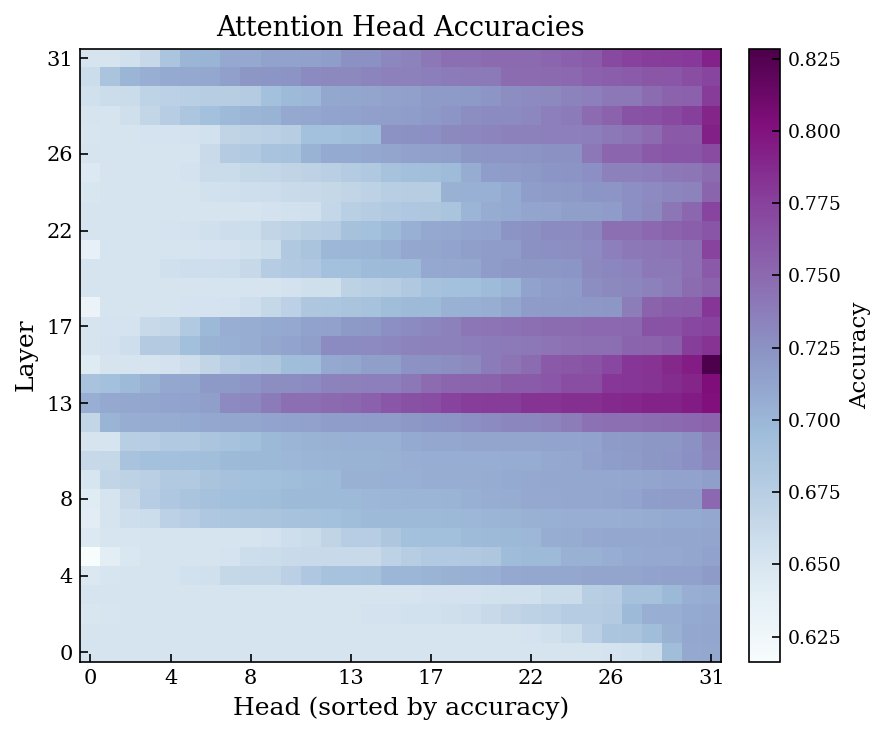

In [51]:
# ── Publication style (if not already set) ──
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "figure.dpi": 150,
})

predictor_accuracy_sorted = np.sort(predictor_accuracies, axis=1)

fig, ax = plt.subplots(figsize=(6, 5))

pos = ax.imshow(predictor_accuracy_sorted, cmap="BuPu", aspect="auto", origin="lower")

ax.set_ylabel("Layer")
ax.set_xlabel("Head (sorted by accuracy)")
ax.set_title("Attention Head Accuracies")

# Move x-axis labels/ticks to bottom (matshow puts them on top)
ax.xaxis.set_ticks_position("bottom")
ax.xaxis.set_label_position("bottom")

# Reduce tick clutter
n_layers, n_heads = predictor_accuracy_sorted.shape
ax.set_xticks(np.linspace(0, n_heads - 1, min(n_heads, 8)).astype(int))
ax.set_yticks(np.linspace(0, n_layers - 1, min(n_layers, 8)).astype(int))

# Colorbar
cbar = fig.colorbar(pos, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Accuracy", fontsize=11)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

In [32]:
# Sort (layer, head) pairs by accuracy descending
# predictor_accuracies is shape (n_layers, n_heads)
flat_sorted_idx = np.argsort(predictor_accuracies.ravel())[::-1]  # descending
sorted_index_pairs = list(zip(*np.unravel_index(flat_sorted_idx, predictor_accuracies.shape)))

# Select top-k attention heads
TOP_K = 5
selected_index_pairs = sorted_index_pairs[:TOP_K]

selected_attn_data = []
for layer, head in selected_index_pairs:
    dataset_idx = layer * 32 + head  # must match how `datasets` was constructed
    X_head, _y = datasets[dataset_idx]
    selected_attn_data.append(X_head)

# Concatenate selected heads' features
X = np.concatenate(selected_attn_data, axis=1) if len(selected_attn_data) > 1 else selected_attn_data[0]
y = labels

accuracies = []
fprs = []
precisions = []
recalls = []
f1s = []
probs = []
test_labels = []
for fold, (train_idx, test_idx) in enumerate(grouped_kfold_split(extracted_df['title'].values)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_bool = np.asarray(y_pred).astype(bool)
    y_true = np.asarray(y_test).astype(bool)

    tp = int(((y_pred_bool == True) & (y_true == True)).sum())
    tn = int(((y_pred_bool == False) & (y_true == False)).sum())
    fp = int(((y_pred_bool == True) & (y_true == False)).sum())
    fn = int(((y_pred_bool == False) & (y_true == True)).sum())

    acc = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else float('nan')
    prec = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    rec = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    f1 = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else float('nan')
    fold_denom = fp + tn
    fpr = (fp / fold_denom) if fold_denom > 0 else float('nan')

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)
    fprs.append(fpr)

    # Per-fold reporting
    n_pos = int(y_true.sum())
    n_neg = int((~y_true).sum())
    print(f"  Fold {fold}: n={len(y_test)} (pos={n_pos}, neg={n_neg}) | "
          f"Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}  FPR={fpr:.4f}")

    # Calibration
    probs.append(model.predict_proba(X_test)[:, 1])
    test_labels.append(y_test)

probs = np.concatenate(probs)
test_labels = np.concatenate(test_labels)

print()
print(f"Attn head model avg. accuracy:   {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"Attn head model avg. precision:  {np.mean(precisions):.4f} ± {np.std(precisions):.4f}")
print(f"Attn head model avg. recall:     {np.mean(recalls):.4f} ± {np.std(recalls):.4f}")
print(f"Attn head model avg. F1:         {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
print(f"Attn head model avg. FPR:        {np.mean(fprs):.4f} ± {np.std(fprs):.4f}")

  Fold 0: n=1441 (pos=814, neg=627) | Acc=0.8286  Prec=0.8105  Rec=0.9091  F1=0.8570  FPR=0.2759
  Fold 1: n=1205 (pos=803, neg=402) | Acc=0.7618  Prec=0.7912  Rec=0.8730  F1=0.8301  FPR=0.4602
  Fold 2: n=1324 (pos=826, neg=498) | Acc=0.8150  Prec=0.8134  Rec=0.9128  F1=0.8602  FPR=0.3474
  Fold 3: n=1138 (pos=903, neg=235) | Acc=0.8699  Prec=0.8912  Rec=0.9524  F1=0.9208  FPR=0.4468
  Fold 4: n=1126 (pos=687, neg=439) | Acc=0.8410  Prec=0.8360  Rec=0.9199  F1=0.8760  FPR=0.2825

Attn head model avg. accuracy:   0.8233 ± 0.0357
Attn head model avg. precision:  0.8285 ± 0.0344
Attn head model avg. recall:     0.9134 ± 0.0254
Attn head model avg. F1:         0.8688 ± 0.0299
Attn head model avg. FPR:        0.3626 ± 0.0785


### Calibration (reliability / trustworthiness)
To check whether the model's predicted probabilities match empirical frequencies (e.g., ~90% of examples with ~0.9 predicted probability are truly positive), we can plot a reliability diagram (calibration curve) and compute calibration metrics like the Brier score.

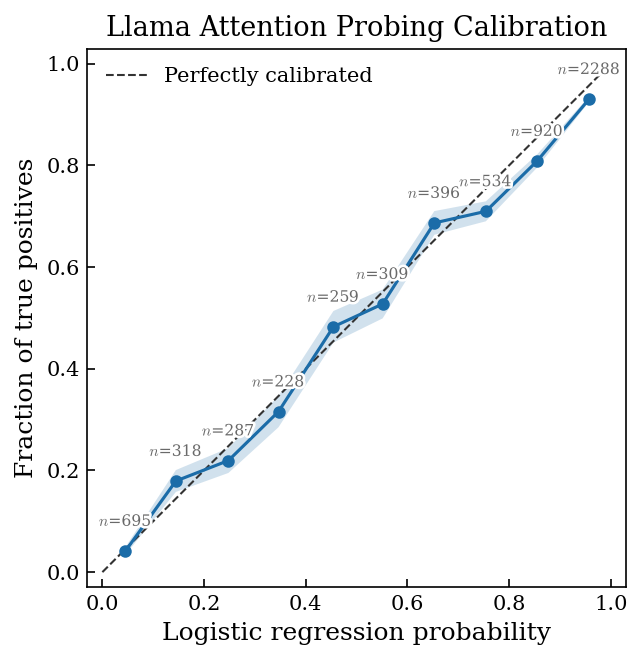

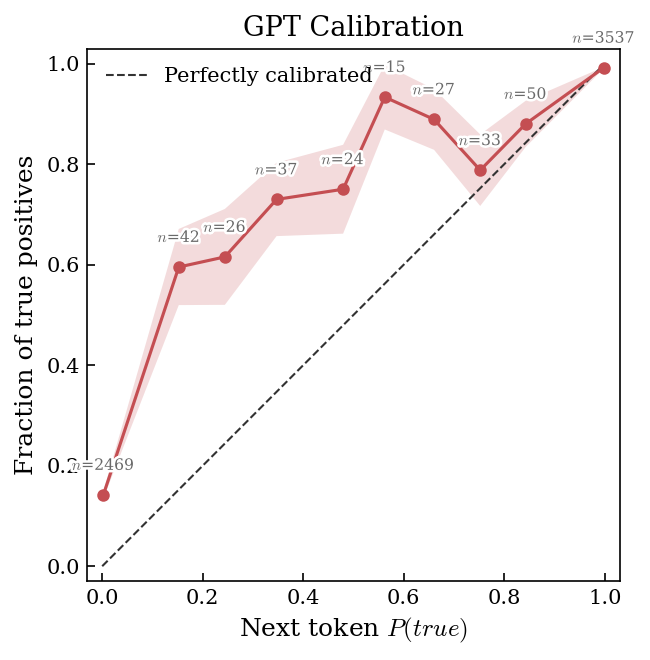

In [50]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import matplotlib.patheffects as pe

# ── Publication style ──
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "figure.dpi": 150,
})

COLORS = {
    "llama": "#1b6ca8",
    "gpt":   "#c44e52",
    "diag":  "#333333",
}


# ── Compute calibration values ──
def compute_calibration(probs, labels, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = []
    bin_means = []
    bin_ses = []
    bin_counts = []
    for b in range(n_bins):
        lo, hi = bin_edges[b], bin_edges[b + 1]
        if b == n_bins - 1:
            mask = (probs >= lo) & (probs <= hi)
        else:
            mask = (probs >= lo) & (probs < hi)
        if mask.sum() == 0:
            continue
        bin_labels = labels[mask].astype(float)
        p = bin_labels.mean()
        n = len(bin_labels)
        bin_centers.append(probs[mask].mean())
        bin_means.append(p)
        bin_ses.append(np.sqrt(p * (1 - p) / n))
        bin_counts.append(n)
    return {
        "centers": np.array(bin_centers),
        "means": np.array(bin_means),
        "ses": np.array(bin_ses),
        "counts": bin_counts,
    }


# ── Plot calibration ──
def plot_calibration(ax, cal, color, label, title, xlabel):
    centers = cal["centers"]
    means = cal["means"]
    ses = cal["ses"]
    counts = cal["counts"]

    # Diagonal
    ax.plot([0, 1], [0, 1], ls="--", color=COLORS["diag"], lw=1,
            label="Perfectly calibrated")

    # Shaded confidence band (±1 SE)
    ax.fill_between(
        centers, means - ses, means + ses,
        alpha=0.2, color=color, edgecolor="none",
    )
    # Main line + markers
    ax.plot(centers, means, "o-", color=color, ms=5, lw=1.5, label=label)

    # Annotate counts with a white outline for legibility
    for x, y, n in zip(centers, means, counts):
        txt = ax.annotate(
            f"$n$={n}", (x, y), textcoords="offset points",
            xytext=(0, 12), ha="center", fontsize=7.5, color="dimgray",
        )
        txt.set_path_effects([
            mpl.patheffects.withStroke(linewidth=2.5, foreground="white"),
        ])

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Fraction of true positives")
    ax.set_title(title)
    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(-0.03, 1.03)
    ax.set_aspect("equal")
    ax.legend(frameon=False, loc="upper left")


# ── Llama ──
cal_llama = compute_calibration(probs, test_labels)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
plot_calibration(
    ax, cal_llama,
    color=COLORS["llama"],
    label=None,
    title="Llama Attention Probing Calibration",
    xlabel="Logistic regression probability",
)
plt.tight_layout()
plt.show()

# ── GPT ──
probs_gpt = extracted_df['judgement_confidence_gpt'].to_numpy()
probs_gpt = np.nan_to_num(probs_gpt, nan=0.0)
test_labels_gpt = labels

cal_gpt = compute_calibration(probs_gpt, test_labels_gpt)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
plot_calibration(
    ax, cal_gpt,
    color=COLORS["gpt"],
    label=None,
    title="GPT Calibration",
    xlabel=r"Next token $P(true)$",
)
plt.tight_layout()
plt.show()